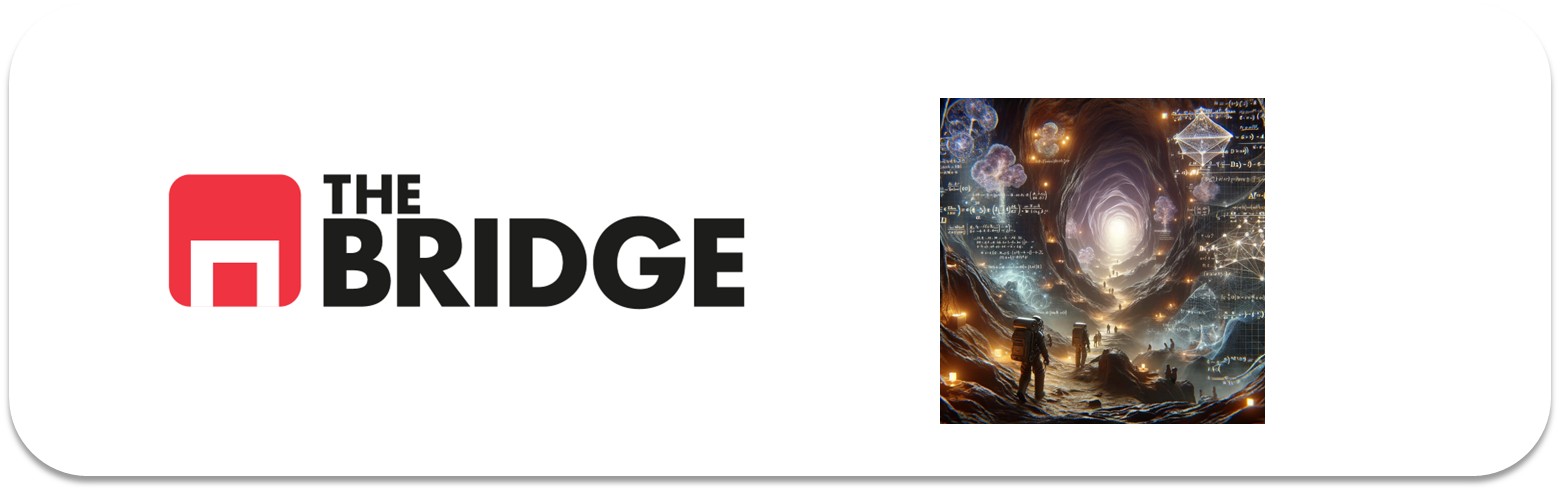

## PRACTICA OBLIGATORIA: **Introducción Deep Learning**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de modelado del dataset del titanic empleando y comparando dos modelos diferentes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [64]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

import bootcampviztools as bt
pd.options.mode.copy_on_write = True

### Descripción y objetivo

El objetivo de la práctica es crear un modelo DL y compararlo con un modelo Random Forest para el dataset de titanic los dos con el mismo objetivo, predecir la supervivencia de un pasajero.  Se pide:  
1. Desarrollar el proceso de ML hasta crear los dos modelos DL y Random Forest. El primero debe tener una topología MLP (es decir una red densa) con un máximo de 3 capas ocultas y debes emplear sklearn para crearlo. No es necesario hacer una análisis/seleccion exahustivo. Escoge una métrica acorde al tipo de target del problema. 

2. Ambos modelos deben tener sus hiperparámetros optimizados, mediante GridSearch. Para ello: utiliza el grid de parámetros que creas conveniente para Random Forest y para el modelo DL, utiliza un grid con los hiperparámetros siguientes:'hidden_layer_sizes','activation', 'solver','alpha' y 'learning_rate'. Para los rangos del grid del modelo de DL guíate por lo visto en el workout y por los posibles valores que se indican en la [documentación](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html#sklearn.neural_network.MLPClassifier). Prueba por lo menos una topología con una sola capa oculta y otra con más de una capa oculta.   
NOTA: Incluye los valores por defecto de los hiperparámetros escogidos en cada caso dentro del grid de hiperparámetros. 
  

3. Compara los modelos respecto a sus métricas medias de accuracy, precision, recall y tiempos de entrenamiento (para ello tendrás que realizar un entrenamiento a parte del mejor modelo obtenido en la optimización de hiperparámetros) y decide cuál te quedarías argumentándolo.    

4. Para el mejor modelo DL obtenido, muestra su clasification report, y la matriz de confusión comentando el resultado.


**Cargar los datos**

In [2]:
df = pd.read_csv("./data/titanic.csv")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


**División train y test**

In [4]:
train_set, test_set = train_test_split(df, test_size= 0.2, random_state= 42)

**Limpieza datos**

In [5]:
train_set_copy = train_set.copy()
test_set_copy = test_set.copy()

In [6]:
# sustituyo los nulos de 'deck' por UNK
train_set["deck"] = train_set["deck"].fillna("UNK")
train_set["deck"].value_counts()

deck
UNK    554
C       52
B       38
E       24
D       19
F       12
A       10
G        3
Name: count, dtype: int64

In [7]:
test_set["deck"] = test_set["deck"].fillna("UNK")
test_set["deck"].value_counts()

deck
UNK    134
D       14
B        9
E        8
C        7
A        5
F        1
G        1
Name: count, dtype: int64

In [8]:
train_set.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [9]:
excluir = ["class", "embark_town", "alive", "adult_male"]
features = [col for col in train_set.columns if col not in excluir and col != "survived"]
print(features)

['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'who', 'deck', 'alone']


In [10]:
train_set.info() 

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 331 to 102
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     712 non-null    int64  
 1   pclass       712 non-null    int64  
 2   sex          712 non-null    object 
 3   age          572 non-null    float64
 4   sibsp        712 non-null    int64  
 5   parch        712 non-null    int64  
 6   fare         712 non-null    float64
 7   embarked     710 non-null    object 
 8   class        712 non-null    object 
 9   who          712 non-null    object 
 10  adult_male   712 non-null    bool   
 11  deck         712 non-null    object 
 12  embark_town  710 non-null    object 
 13  alive        712 non-null    object 
 14  alone        712 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 79.3+ KB


In [11]:
test_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 179 entries, 709 to 10
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     179 non-null    int64  
 1   pclass       179 non-null    int64  
 2   sex          179 non-null    object 
 3   age          142 non-null    float64
 4   sibsp        179 non-null    int64  
 5   parch        179 non-null    int64  
 6   fare         179 non-null    float64
 7   embarked     179 non-null    object 
 8   class        179 non-null    object 
 9   who          179 non-null    object 
 10  adult_male   179 non-null    bool   
 11  deck         179 non-null    object 
 12  embark_town  179 non-null    object 
 13  alive        179 non-null    object 
 14  alone        179 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 19.9+ KB


In [12]:
# Imputar por la moda los faltante de 'embarked'
imp = SimpleImputer(strategy= "most_frequent")

train_set[["embarked"]] = imp.fit_transform(train_set[["embarked"]])
test_set[["embarked"]] = imp.transform(test_set[["embarked"]])

In [13]:
# Imputar los nulos de 'age' por la mediana agrupando por 'who'
es_hombre = train_set.who == "man"
es_mujer = train_set.who == "woman"
es_child = train_set.who == "child"

median_man = train_set[es_hombre]["age"].median()
median_woman = train_set[es_mujer]["age"].median()
median_child = train_set[es_child]["age"].median()

es_nulo = train_set.age.isna()
es_nulo_test = test_set.age.isna()

#Imputamos en train
train_set.loc[es_hombre & es_nulo, "age"] = median_man
train_set.loc[es_mujer & es_nulo, "age"] = median_woman
train_set.loc[es_child & es_nulo, "age"] = median_child

#Imputamos en test
test_set.loc[(test_set.who == "man") & es_nulo_test, "age"] = median_man
test_set.loc[(test_set.who == "woman") & es_nulo_test, "age"] = median_woman
test_set.loc[(test_set.who == "child") & es_nulo_test, "age"] = median_child

In [14]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 331 to 102
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     712 non-null    int64  
 1   pclass       712 non-null    int64  
 2   sex          712 non-null    object 
 3   age          712 non-null    float64
 4   sibsp        712 non-null    int64  
 5   parch        712 non-null    int64  
 6   fare         712 non-null    float64
 7   embarked     712 non-null    object 
 8   class        712 non-null    object 
 9   who          712 non-null    object 
 10  adult_male   712 non-null    bool   
 11  deck         712 non-null    object 
 12  embark_town  710 non-null    object 
 13  alive        712 non-null    object 
 14  alone        712 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 79.3+ KB


In [15]:
test_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 179 entries, 709 to 10
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     179 non-null    int64  
 1   pclass       179 non-null    int64  
 2   sex          179 non-null    object 
 3   age          179 non-null    float64
 4   sibsp        179 non-null    int64  
 5   parch        179 non-null    int64  
 6   fare         179 non-null    float64
 7   embarked     179 non-null    object 
 8   class        179 non-null    object 
 9   who          179 non-null    object 
 10  adult_male   179 non-null    bool   
 11  deck         179 non-null    object 
 12  embark_town  179 non-null    object 
 13  alive        179 non-null    object 
 14  alone        179 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 19.9+ KB


In [16]:
# alone: bool --> int
train_set["alone"] = train_set["alone"].astype(int)
test_set["alone"] = test_set["alone"].astype(int)

**Mini-EDA**

In [17]:
target = "survived"

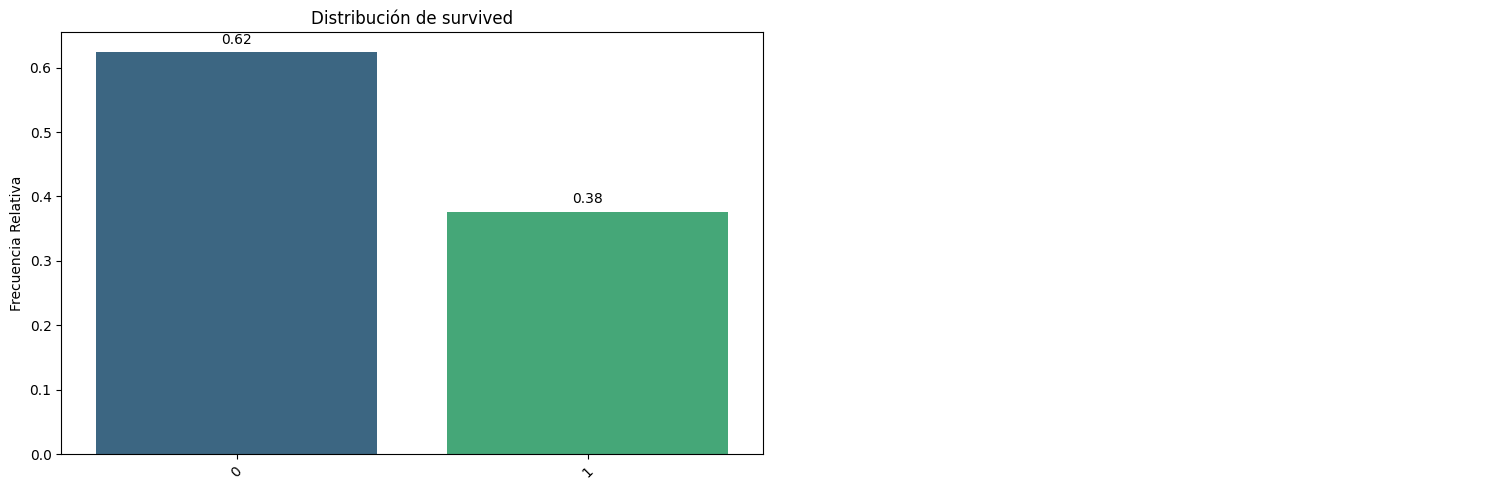

In [18]:
bt.pinta_distribucion_categoricas(train_set, [target], relativa= True, mostrar_valores= True)

Cierto desbalanceo pero no exagerado

In [19]:
print(features)

['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'who', 'deck', 'alone']


In [20]:
train_set[features].head(1)

,pclass,sex,age,sibsp,parch,fare,embarked,who,deck,alone
331,1,male,45.5,0,0,28.5,S,man,C,1


In [21]:
features_num = ["age", "sibsp", "parch", "fare"]
features_cat = [col for col in features if col not in features_num and col]
print(features_cat)

['pclass', 'sex', 'embarked', 'who', 'deck', 'alone']


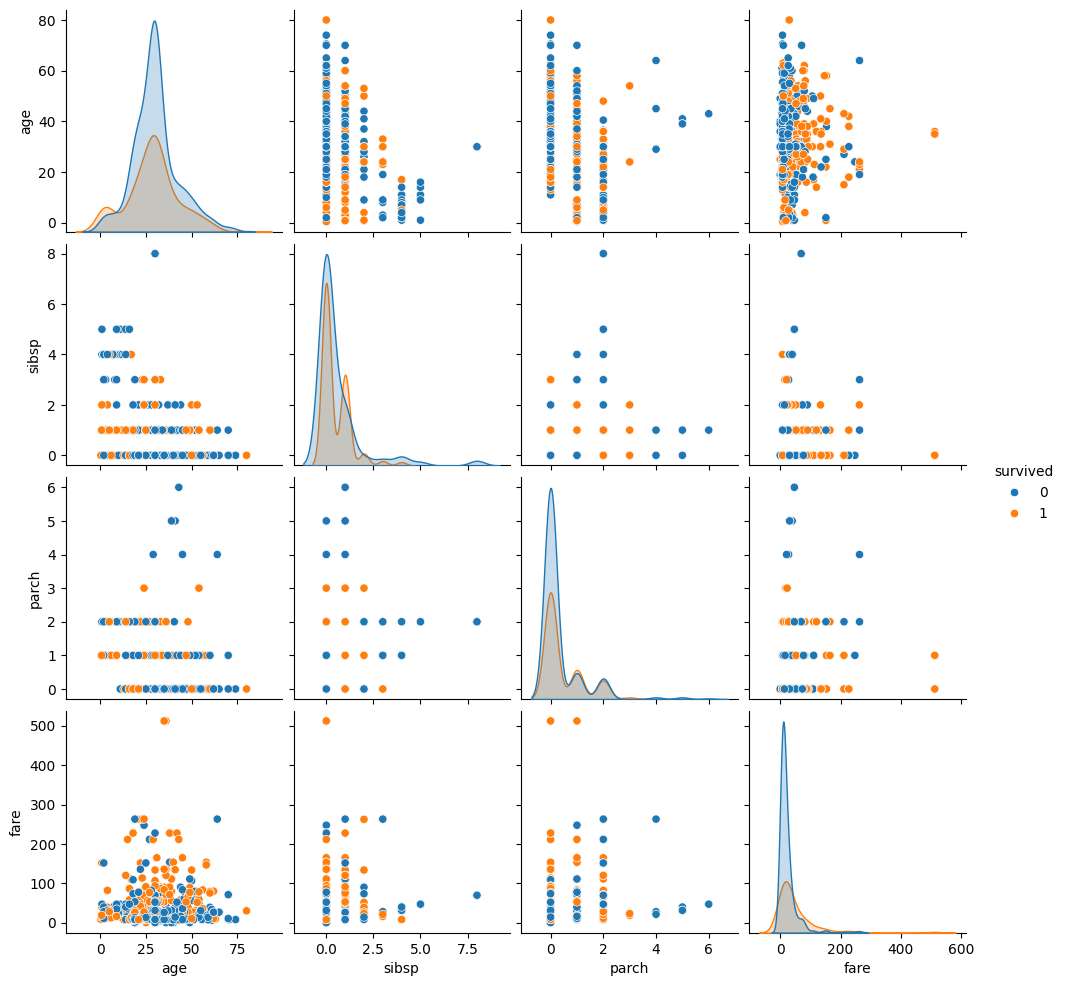

In [22]:
sns.pairplot(train_set[features_num + [target]], hue = target)

Target vs categóricas

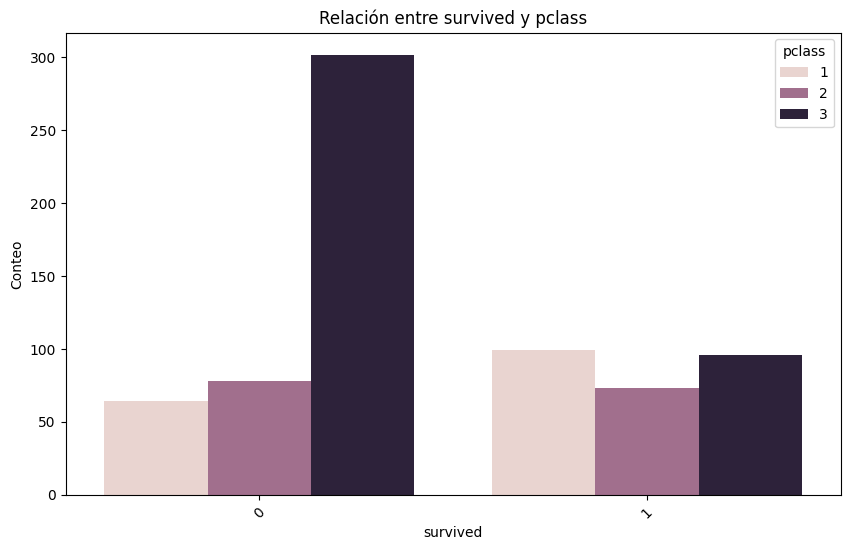

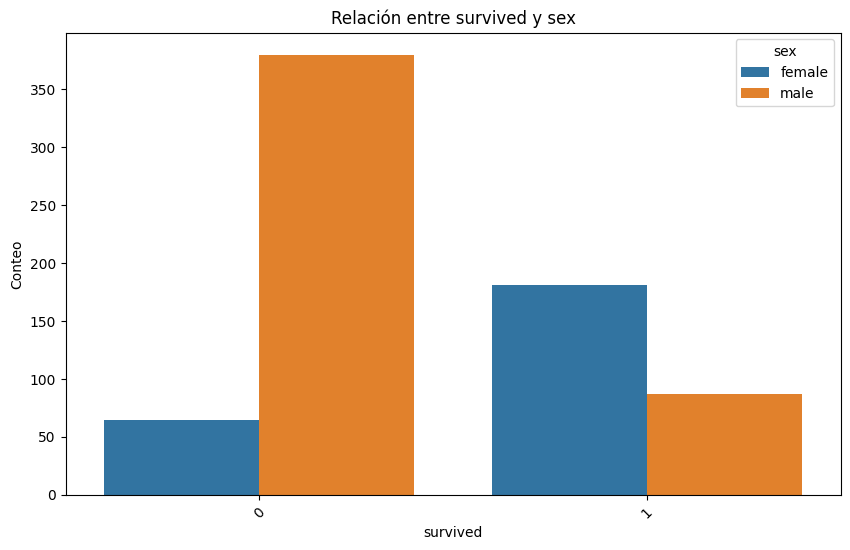

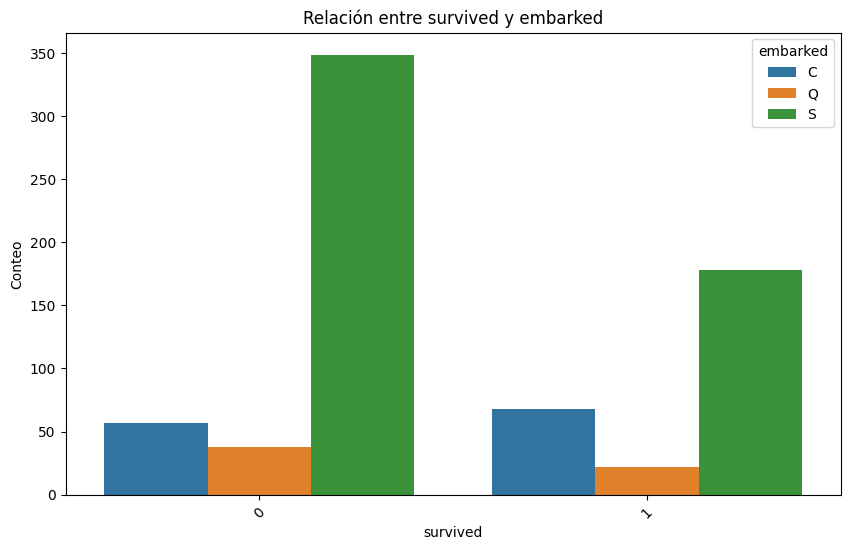

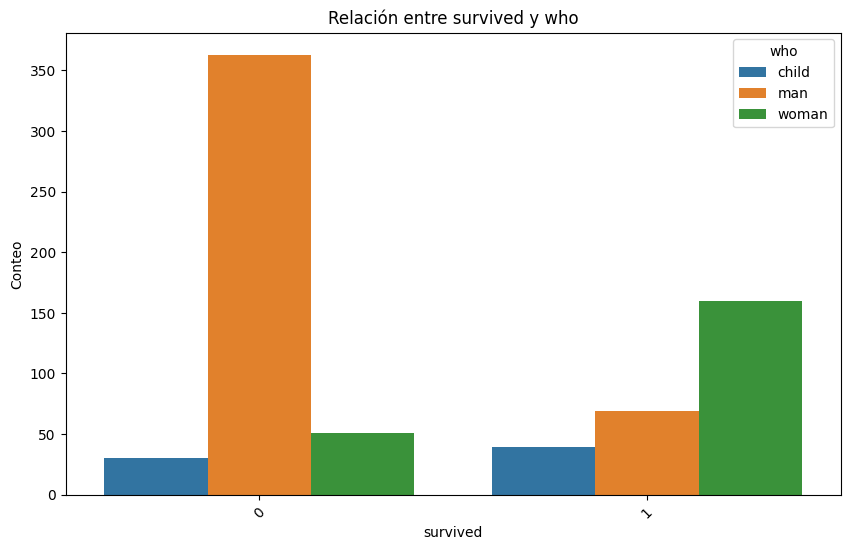

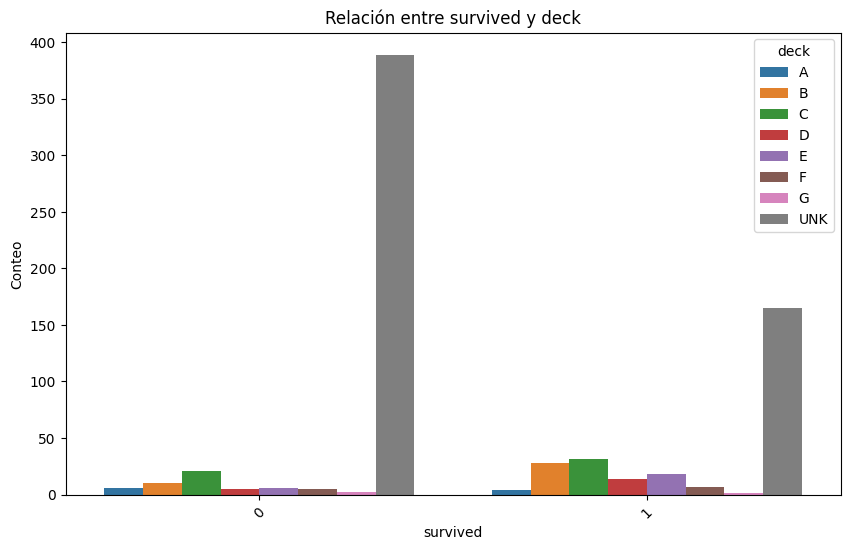

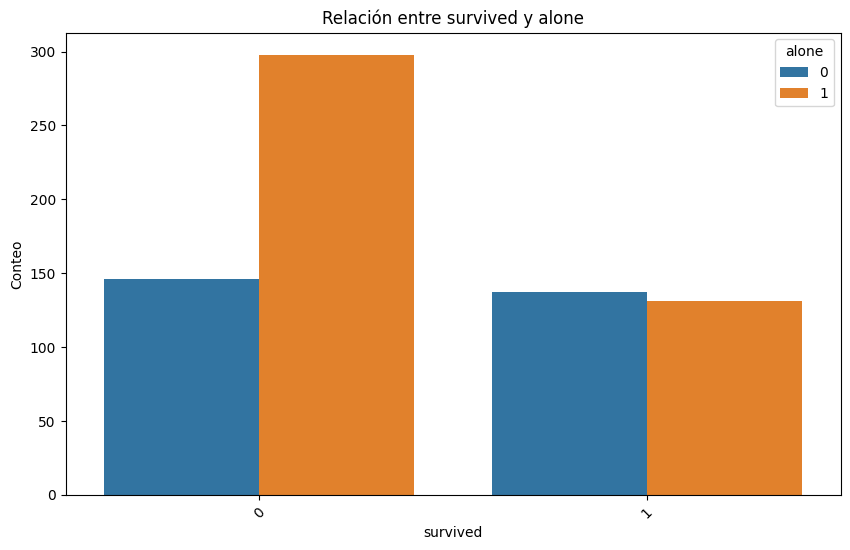

In [23]:
for col in features_cat:
    bt.plot_categorical_relationship_fin(train_set, target, col)

In [24]:
# nueva variable: deck_informed (binaria)
train_set["deck_informed"] = (train_set.deck != "UNK").astype(int)
test_set["deck_informed"] = (test_set.deck != "UNK").astype(int)

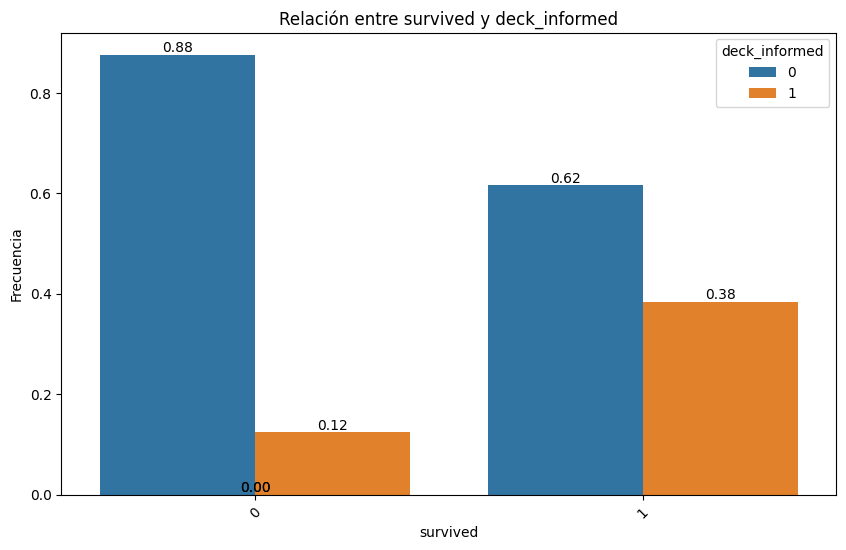

In [25]:
bt.plot_categorical_relationship_fin(train_set, target,"deck_informed", show_values= True, relative_freq= True)

In [26]:
features_cat.remove("deck")
features_cat.append("deck_informed")

In [27]:
features_cat

['pclass', 'sex', 'embarked', 'who', 'alone', 'deck_informed']

Me quedo con todas

Target vs numéricas

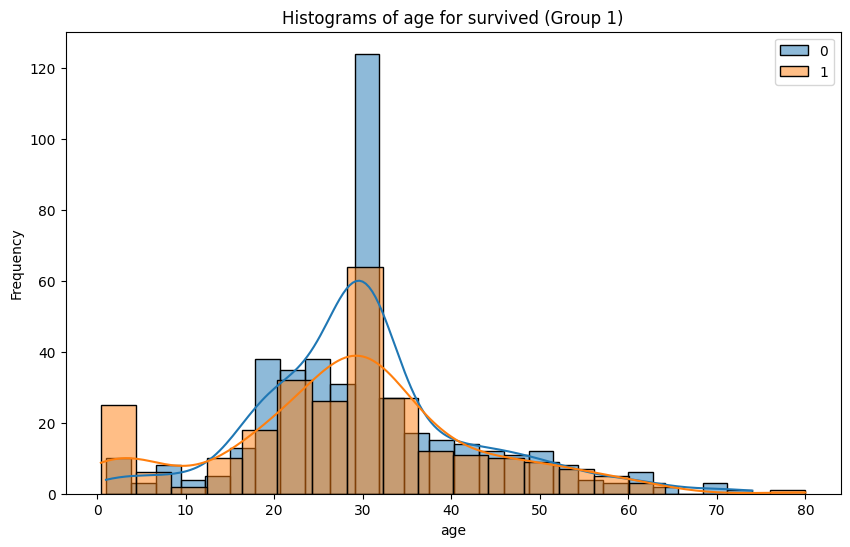

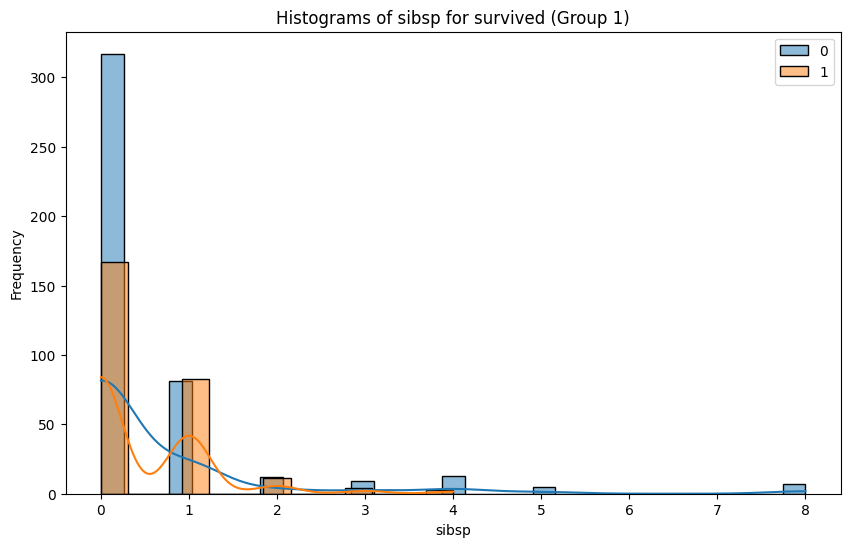

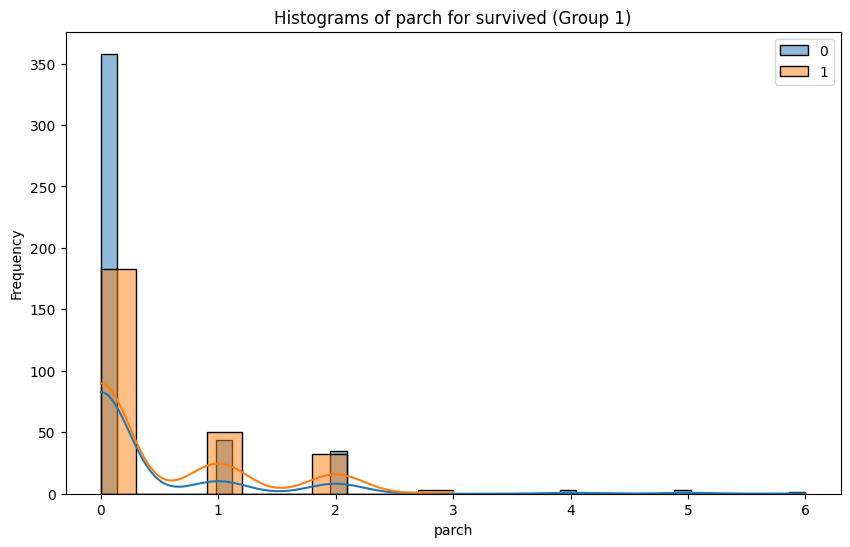

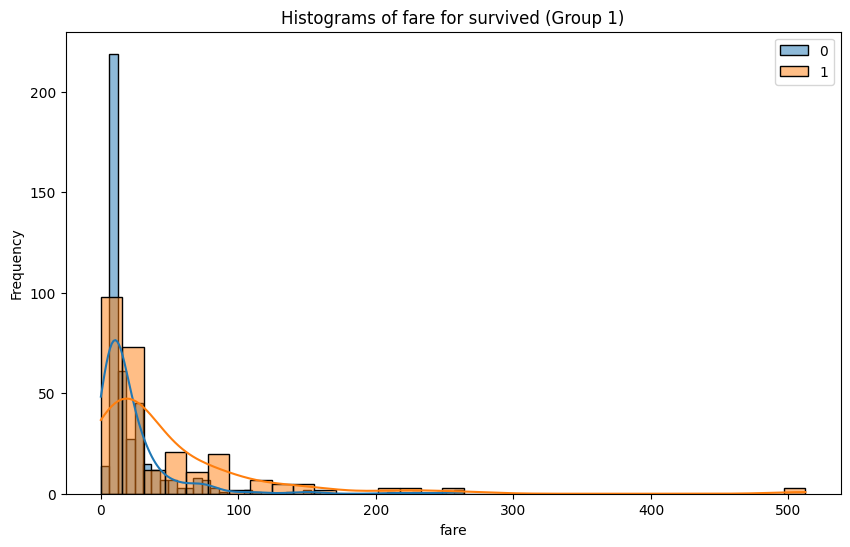

In [28]:
for col in features_num:
    bt.plot_grouped_histograms(train_set, cat_col= target, num_col= col, group_size= 2)

Ya se veía en el pairplot inicial que 'parch' no discrimina, la descarto

In [29]:
features_num.remove("parch")

In [30]:
features_final = features_num + features_cat
print(features_final)

['age', 'sibsp', 'fare', 'pclass', 'sex', 'embarked', 'who', 'alone', 'deck_informed']


**Tratamiento**

Categóricas

In [31]:
categorias = [["female", "male"], ["S", "C", "Q"], ["child", "woman", "man"]]

encoder = OrdinalEncoder(categories= categorias)
train_set[["sex", "embarked", "who"]] = encoder.fit_transform(train_set[["sex", "embarked", "who"]])
test_set[["sex", "embarked", "who"]] = encoder.transform(test_set[["sex", "embarked", "who"]])

Numéricas

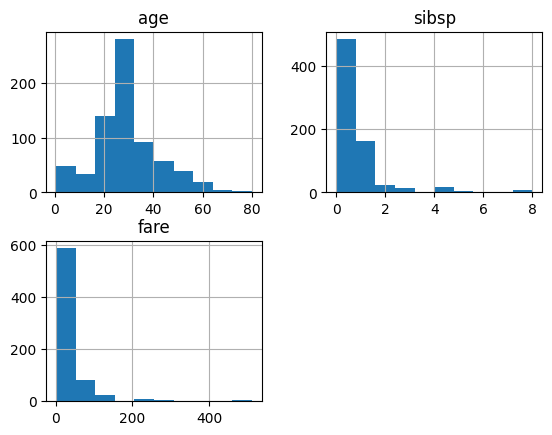

In [32]:
train_set[features_num].hist();

In [33]:
train_set["fare"].value_counts().sort_index()

fare
0.0000      13
4.0125       1
5.0000       1
6.2375       1
6.4375       1
            ..
227.5250     4
247.5208     1
262.3750     1
263.0000     4
512.3292     3
Name: count, Length: 220, dtype: int64

In [34]:
train_set["sibsp"].value_counts().sort_index()

sibsp
0    484
1    164
2     23
3     13
4     16
5      5
8      7
Name: count, dtype: int64

In [35]:
train_set_scaled = train_set.copy()
test_set_scaled = test_set.copy()

In [36]:
# aplicar logaritmo a 'sibsp' y 'fare'18_Practica_Obligatoria_Introduccion_Deep_Learning.ipynb
train_set_scaled["fare"] = train_set_scaled["fare"].apply(np.log1p)
test_set_scaled["fare"] = test_set_scaled["fare"].apply(np.log1p)

train_set_scaled["sibsp"] = train_set_scaled["sibsp"].apply(np.log1p)
test_set_scaled["sibsp"] = test_set_scaled["sibsp"].apply(np.log1p)

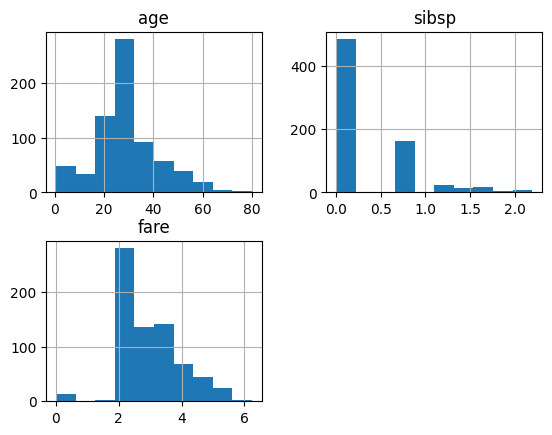

In [37]:
train_set_scaled[features_num].hist();

**Escalado**

In [38]:
scaler = StandardScaler()

train_set_scaled[features_num] = scaler.fit_transform(train_set_scaled[features_num])
test_set_scaled[features_num] = scaler.transform(test_set_scaled[features_num])

In [39]:
train_set_scaled[features_num].describe()

,age,sibsp,fare
count,7.120000e+02,7.120000e+02,7.120000e+02
mean,9.730044e-17,2.619627e-17,-1.871162e-17
std,1.000703e+00,1.000703e+00,1.000703e+00
min,-2.246712e+00,-6.085111e-01,-3.015126e+00
25%,-5.850128e-01,-6.085111e-01,-7.822006e-01
50%,3.100189e-02,-6.085111e-01,-2.221223e-01
75%,4.160111e-01,8.418805e-01,5.043216e-01
max,3.881094e+00,3.989121e+00,3.351442e+00


**Modelado**

In [40]:
X_train = train_set[features_final]
X_train_scaled = train_set_scaled[features_final]
y_train = train_set[target]

X_test = test_set[features_final]
X_test_scaled = test_set_scaled[features_final]
y_test = test_set[target]

DL

In [45]:
mlp = MLPClassifier(max_iter = 1000, random_state= 42)

Random Forest

In [42]:
rf = RandomForestClassifier(max_depth= 5, random_state= 42)

**Optimización**

DL

In [43]:
len(features_final)

9

In [46]:
param_grid_mlp = {
    "hidden_layer_sizes": [
        (50,), # 1 capa
        (100, ), # valor por defecto
        (50, 50), # 2 capas
        (100, 50),
        (50, 50, 50) # 3 capas
    ],
    "activation": ["logistic", "relu"], # por defecto relu
    "solver": ["sgd", "adam"], # por defecto adam
    "alpha": [0.1, 0.01, 0.001, 0.0001], # por defecto 0.0001
    "learning_rate": ["constant", "adaptive"] # por defecto constant
}

grid_mlp = GridSearchCV(
    estimator = mlp,
    param_grid = param_grid_mlp,
    cv = 5, 
    scoring = "f1", # uso f1 en vez de accuracy por el desbalanceo del target, aunque no sea mucho
    n_jobs = -1
)

grid_mlp.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPClassifier...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'activation': ['logistic', 'relu'], 'alpha': [0.1, 0.01, ...], 'hidden_layer_sizes': [(50,), (100,), ...], 'learning_rate': ['constant', 'adaptive'], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation 

In [47]:
best_mlp = grid_mlp.best_estimator_
print("Mejores hiperparámetros:", grid_mlp.best_params_)
print("Mejor score CV:", grid_mlp.best_score_)

Mejores hiperparámetros: {'activation': 'relu', 'alpha': 0.1, 'hidden_layer_sizes': (50, 50, 50), 'learning_rate': 'constant', 'solver': 'sgd'}
Mejor score CV: 0.7439206304531382


Random Forest

In [49]:
param_grid_rf = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10, 15, None],
    "min_samples_split": [2, 5, 7],
    "min_samples_leaf": [1, 2, 3],
    "max_features": ["sqrt", "log2"], # por defecto sqrt
    "class_weight": ["balanced", None]
}

grid_rf = GridSearchCV(
    estimator = rf,
    param_grid = param_grid_rf,
    cv = 5, 
    scoring = "f1", 
    n_jobs = -1
)

grid_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced', None], 'max_depth': [3, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold an

In [55]:
best_rf = grid_rf.best_estimator_
print("Mejores hiperparámetros:", grid_rf.best_params_)
print("Mejor score CV:", grid_rf.best_score_)

Mejores hiperparámetros: {'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Mejor score CV: 0.7555286871392637


**Comparación**

In [56]:
start = time.time()
best_mlp.fit(X_train_scaled, y_train)
end = time.time()

training_time_mlp = end - start
print(f"Tiempo de entrenamiento de MLP: {training_time_mlp:.4f} segundos")

Tiempo de entrenamiento de MLP: 4.9247 segundos


In [58]:
start = time.time()
best_rf.fit(X_train, y_train)
end = time.time()

training_time_rf = end - start
print(f"Tiempo de entrenamiento de RF: {training_time_rf:.4f} segundos")

Tiempo de entrenamiento de RF: 0.2662 segundos


In [60]:
y_pred_mlp = best_mlp.predict(X_test_scaled)

print(classification_report(y_test, y_pred_mlp))

              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [ ]:
y_pred_mlp = best_mlp.predict(X_test_scaled)

print(classification_report(y_test, y_pred_mlp))

              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [61]:
y_pred_rf = best_rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



*Random Forest presenta mejores valores en las tres métricas y además el tiempo de entrenamiento es bastante mejor. Por lo tanto, me quedaría con RF.*

**Evaluación mejor DL**

In [ ]:
y_pred_mlp = best_mlp.predict(X_test_scaled)

print(classification_report(y_test, y_pred_mlp))

              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



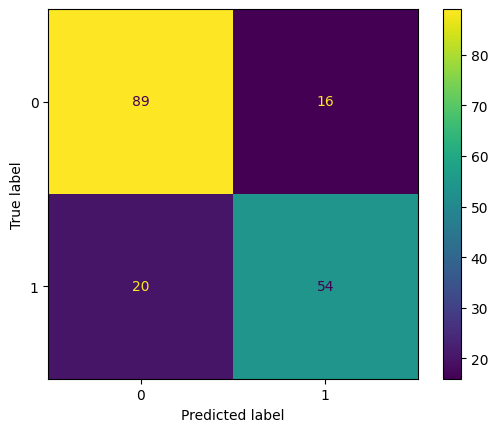

In [68]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_mlp);